In [9]:
from langchain.chat_models import init_chat_model
from dotenv import load_dotenv
load_dotenv()

model = init_chat_model(
    "google_genai:gemini-2.5-flash",
    temperature = 0
)

In [10]:
from typing import TypedDict

class State(TypedDict):
    question: str
    easy_explanation: str
    practical_usage: str
    future_outlook: str
    final_answer: str

In [11]:
from langchain_core.messages import SystemMessage, HumanMessage

def easy_explain_node(state: State):
    system_prompt = """당신은 초등학생도 이해할 수 있도록 쉽게 설명하는 선생님입니다.
어려운 개념도 누구나 알 수 있게 최대한 쉽고 간단히 설명해 주세요."""

    user_prompt = f'{state['question']}'

    messages = [
        SystemMessage(content=system_prompt),
        HumanMessage(content=user_prompt)
    ]

    response = model.invoke(messages)

    return {"easy_explanation": response.content}

def practical_node(state: State):
    system_prompt = """당신은 실용주의 개발자이자 엔지니어입니다.
이론보다는 실제로 어떻게 쓰는지의 활용법이나 사례 중심으로 간단히 설명해 주세요."""

    user_prompt = f'{state['question']}'

    messages = [
        SystemMessage(content=system_prompt),
        HumanMessage(content=user_prompt)
    ]

    response = model.invoke(messages)

    return {"practical_usage": response.content}

def future_node(state: State):
    system_prompt = """당신은 기술 트렌드와 미래를 예측하는 전문가입니다.
향후 발전할 방향, 기회, 위험을 중심으로 간단히 설명해 주세요."""

    user_prompt = f'{state['question']}'

    messages = [
        SystemMessage(content=system_prompt),
        HumanMessage(content=user_prompt)
    ]

    response = model.invoke(messages)

    return {"future_outlook": response.content}

In [12]:
def combine_node(state: State):
    system_prompt = f"""다음 세 가지의 답변을 연결하여 통합된 설명을 작성해 주세요.
불필요한 반복은 줄이고, 자연스럽게 연결시켜 주세요.

- 초등학생도 이해할 수 있는 설명: {state.get('easy_explanation', '')}
- 실 개발자의 실제 활용법 또는 예제 중심의 설명: {state.get('practical_usage', '')}
- 미래 예측 전문가의 향후 전망 중심의 설명: {state.get('future_outlook', '')}"""

    user_prompt = f"{state['question']}"

    messages = [
        SystemMessage(content=system_prompt),
        HumanMessage(content=user_prompt),
    ]

    response = model.invoke(messages)

    return {"final_answer": response.content}

In [13]:
from langgraph.graph import StateGraph, START, END

graph_builder = StateGraph(State)

graph_builder.add_node("easy_explain", easy_explain_node)
graph_builder.add_node("practical", practical_node)
graph_builder.add_node("future", future_node)
graph_builder.add_node("combine", combine_node)

graph_builder.add_edge(START, "easy_explain")
graph_builder.add_edge(START, "practical")
graph_builder.add_edge(START, "future")

graph_builder.add_edge("easy_explain", "combine")
graph_builder.add_edge("practical", "combine")
graph_builder.add_edge("future", "combine")

graph_builder.add_edge("combine", END)

graph = graph_builder.compile()

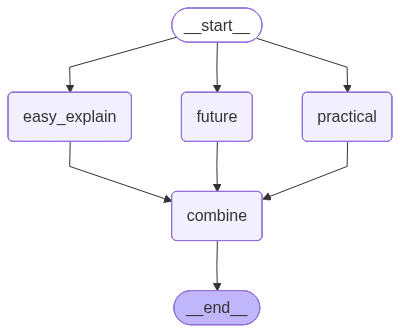

In [14]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [15]:
result = graph.invoke({"question": "Langgraph란?"})

In [18]:
print(result['final_answer'])

안녕! 오늘은 '랭그래프(LangGraph)'라는 재미있는 친구를 만나볼 거야. 이름은 좀 어렵지만, 우리 AI 친구들이 훨씬 더 똑똑하고 복잡한 일을 잘 해낼 수 있게 도와주는 아주 특별한 도구란다.

혹시 '챗GPT' 같은 인공지능(AI) 친구들 알지? 우리가 질문하면 척척 대답해 주는 똑똑한 친구들 말이야. 그런데 이 AI 친구들이 한 번에 딱 한 가지 일만 할 수 있다면 어떨까? 예를 들어, '사과에 대해 알려줘!' 하면 사과 정보만 알려주고 끝나는 거지.

하지만 실제 세상의 일들은 훨씬 복잡해. 마치 "오늘 날씨를 알려주고, 만약 비가 오면 우산 챙기라고 말해줘. 그리고 비가 안 오면 밖에 나가서 놀기 좋은지 알려줘!" 같은 여러 단계를 거치고, 중간에 '만약 ~라면' 하고 스스로 판단해야 하는 일들 말이야. 이런 복잡한 부탁은 AI가 한 번에 다 알아듣고 하기가 어려워.

바로 이때 **'랭그래프(LangGraph)'**가 나타나서 도와주는 거야! 랭그래프는 AI 친구에게 **'어떤 일을 어떤 순서대로 할지'** 알려주는 **'특별한 지도'**나 **'계획표'** 같은 거라고 생각하면 돼.

실용적인 관점에서 보면, 랭그래프는 LLM(대규모 언어 모델)을 활용한 복잡한 애플리케이션을 만들 때, 마치 **흐름도(Flowchart)나 상태 머신(State Machine)처럼 여러 단계를 유연하게 연결하고 제어할 수 있게 해주는 도구**야. 각 단계에서 수행할 작업(예: LLM 호출, 외부 도구 사용, 조건 판단)을 **'노드(Node)'**로 정의하고, 이 노드들 사이의 흐름을 **'엣지(Edge)'**로 연결해. 특히, 엣지는 특정 노드의 결과에 따라 다음 노드를 다르게 선택하는 **조건부 분기**를 가능하게 해서, AI가 스스로 판단하고 여러 길로 갈 수 있도록 돕지. 이 과정에서 사용자의 질문, LLM의 중간 답변, 도구 검색 결과 같은 모든 정보는 **'상태(State)'**로 공유되며 계속 업데이트돼.

이러한 구조 덕분에 랭그래프는 단순한 